# 🏢 Familia B — Barra Habitacional con Corredor Central 

Este notebook define, parametriza y visualiza la **Familia B** de edificios: una barra habitacional de hormigón armado con corredor central longitudinal y núcleo de circulación vertical (ascensores + escalera) ubicado en el centro de la planta.

La Familia B es una de las tipologías más habituales del parque habitacional chileno de mediana altura. Su lógica de organización interna es consistente y repetible, lo que la hace especialmente apta para ser parametrizada y usada como dominio de entrenamiento de una PINN.

---

El notebook está organizado en las siguientes secciones:

1. Librerías
2. Configuración general de la familia
3. Utilidades geométricas
4. Construcción de parámetros derivados
5. Geometría de muros y módulos
6. Tablas de variables y grupos de muros
7. Visualización en planta y 3D
8. Configuración del caso base y ejecución

## 📦 Librerías utilizadas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from IPython.display import display
from pprint import pprint

## ⚙️ Configuración general: `FAMILIA_B_CFG`

Todo el conocimiento de la familia vive en un único diccionario, `FAMILIA_B_CFG`, con cuatro secciones:

- **`fixed`** — parámetros que fijan la *identidad* de la tipología y no varían entre instancias: 2 módulos por departamento, 1 bahía técnica por lado, grupos de muros B3 y B4 siempre activos, valores normativos por defecto (carga viva NCh1537, factor de combinación ψ NCh433) y las **salvaguardas de familia** (área de unidad en [30, 60] m², relación de aspecto mínima $L_x/L_y \geq 1.75$, fracción de núcleo $B_{nucleo}/L_y \leq 0.45$).
- **`variable_ranges`** — el **dominio paramétrico** que se muestrea para generar el dataset: programa habitacional, dimensiones del núcleo, altura, material y cargas, espesores y largos de muros, y la activación del grupo B2.
- **`wall_groups`** — la descripción de los cuatro grupos de muros (B1–B4): nombre, estado, dirección de aporte y rol.
- **`defaults`** — los valores del **caso base** que se usan cuando no se muestrea aleatoriamente.

**Se obtiene:** el objeto `FAMILIA_B_CFG`, fuente única de verdad para todo lo que sigue.

In [2]:
FAMILIA_B_CFG = {
    "meta": {
        "family_name": "Familia B",
        "description": (
            "Barra habitacional con corredor central longitudinal, "
            "núcleo central (ASC1 + ESC + ASC2), misma cantidad de módulos "
            "a ambos lados del núcleo y departamentos formados por 2 módulos."
        )
    },

    # ── IDENTIDAD / RESTRICCIONES BASE ───────────────────────────────────────
    "fixed": {
        "tipologia":                "barra_habitacional",
        "circulacion":              "corredor_central_longitudinal",
        "nucleo_tipo":              "asc1_esc_asc2",
        "mods_por_depto":           2,        # siempre 2 módulos por depto — constante v6
        "activar_B3":               1,        # muros medianeros siempre activos — constante v6
        "activar_B4":               1,        # muros borde corredor siempre activos
        "muros_variables_en_pares": True,
        "categoria_uso":            "habitacional",
        "suelo_default":            "D",
        "qk_default_kN_m2":         2.0,      # carga viva NCh1537 habitacional
        "psi_default":              0.25,     # factor combinación sísmica NCh433 Art.6.3.2

        # criterios de familia (salvaguardas programáticas)
        "area_unidad_min_m2":       30.0,     # nunca activo — mín real dataset v6 = 44.8 m²
        "area_unidad_max_m2":       60.0,     # máx real dataset v6 = 60.0 m²
        "aspect_ratio_min":         1.75,     # Lx/Ly mínimo para tipología barra
        "B_nucleo_frac_Ly_max":     0.45,     # núcleo ≤ 45% del ancho Ly
        "tech_bays_each_side":      1,        # 1 bahía técnica a cada lado del núcleo
        "lw_max_m":                 100.0,    # filtro largo edificio — práctico ≤ 100 m
    },

    # ── VARIABLES LIBRES ──────────────────────────────────────────────────────
    "variable_ranges": {
        # programa habitacional
        "n_unid_lado":       {"type": "int",    "min": 2,    "max": 6},    # dataset v6: [2,3,4,5,6]
        "L_mod_m":           {"type": "float",  "min": 3.20, "max": 3.80},
        "prof_depto_m":      {"type": "float",  "min": 7.00, "max": 7.90},
        "ancho_corredor_m":  {"type": "float",  "min": 1.50, "max": 1.90},
        "eficiencia_planta": {"type": "float",  "min": 0.74, "max": 0.82},

        # núcleo
        "L_nucleo_m":             {"type": "float", "min": 5.40, "max": 6.60},
        "B_nucleo_m":             {"type": "float", "min": 4.00, "max": 5.00},
        "gap_core_to_corridor_m": {"type": "float", "min": 0.00, "max": 0.20},

        # altura
        "N_pisos":   {"type": "int",    "min": 6,   "max": 18},
        "h_story_m": {"type": "choice", "values": [2.60, 2.70, 2.80, 2.90]},

        # material y cargas
        "fc_MPa":   {"type": "choice", "values": [25, 30, 35, 40]},
        "gk_kN_m2": {"type": "choice", "values": [6.0, 6.5, 7.0, 7.5]},
        "zona":     {"type": "choice", "values": [1, 2, 3]},
        "suelo":    {"type": "choice", "values": ["A", "B", "C", "D"]},

        # muros — espesores
        "t_muro_nucleo_m": {"type": "choice",
                            "values": [0.18, 0.20, 0.22, 0.25, 0.28, 0.30]},
        "t_muro_borde_m":  {"type": "choice",
                            "values": [0.15, 0.18, 0.20, 0.22, 0.25]},
        "t_muro_mid_m":    {"type": "choice",
                            "values": [0.15, 0.18, 0.20, 0.22, 0.25]},
        "lw_borde_m":      {"type": "choice",
                            "values": [2.0, 2.2, 2.4, 2.6, 2.8, 3.0,
                                       3.2, 3.4, 3.6, 3.8, 4.0]},
        "lw_mid_m":        {"type": "choice",
                            "values": [2.0, 2.2, 2.4, 2.6, 2.8, 3.0,
                                       3.2, 3.4, 3.6, 3.8, 4.0]},

        # activación grupos opcionales
        # B2: muros de fachada exterior — variable {0,1}
        # B3: medianeros — FIJO=1, movido a fixed (constante en v6)
        # B4: muros borde corredor — FIJO=1, siempre activo
        "activar_B2": {"type": "choice", "values": [0, 1]},
    },

    # ── GRUPOS DE MUROS ───────────────────────────────────────────────────────
    "wall_groups": {
        "B1": {
            "name":           "Muros del núcleo",
            "state":          "obligatorio",
            "main_role":      "núcleo central — rigidez básica X e Y",
            "main_direction": "X + Y",
            "paired":         False,
            "activar_var":    None,   # siempre activo
        },
        "B2": {
            "name":           "Muros de fachada exterior (extremos longitudinales)",
            "state":          "opcional — variable activar_B2 ∈ {0,1}",
            "main_role":      "control global de deriva en Y",
            "main_direction": "principalmente Y",
            "paired":         True,
            "activar_var":    "activar_B2",
        },
        "B3": {
            "name":           "Muros medianeros entre departamentos",
            "state":          "obligatorio — fijo activar_B3=1 en dataset v6",
            "main_role":      "rigidez distribuida en Y — regularidad estructural",
            "main_direction": "principalmente Y",
            "paired":         True,
            "activar_var":    None,   # constante en v6
        },
        "B4": {
            "name":           "Muros de borde del corredor (pasillo)",
            "state":          "obligatorio — siempre activo",
            "main_role":      "rigidez longitudinal X — confinamiento corredor",
            "main_direction": "principalmente X",
            "paired":         True,
            "activar_var":    None,   # siempre activo
        },
    },

    # ── CASO BASE (defaults) — edificio representativo ────────
    #   N_pisos ~ 12, n_unid_lado ~ 3.65, gk ~ 6.75, zona uniforme 1-2-3
    "defaults": {
        "n_unid_lado":            4,      
        "L_mod_m":                3.50,  
        "prof_depto_m":           7.50,
        "ancho_corredor_m":       1.70,   
        "eficiencia_planta":      0.78,
        "L_nucleo_m":             6.00,   
        "B_nucleo_m":             4.50,   
        "gap_core_to_corridor_m": 0.10,
        "N_pisos":                12,     
        "h_story_m":              2.70,   
        "fc_MPa":                 30,
        "gk_kN_m2":               7.0,    
        "zona":                   2,      
        "suelo":                  "D",
        "t_muro_nucleo_m":        0.25,   
        "t_muro_borde_m":         0.20,   
        "t_muro_mid_m":           0.20,   
        "lw_borde_m":             3.20,
        "lw_mid_m":               2.80,
        "activar_B2":             1,
        "activar_B3":             1,      
    }
}

## 🧱 Grupos de muros: B1, B2, B3 y B4

El sistema sismorresistente se organiza en **cuatro grupos**, definidos en `FAMILIA_B_CFG["wall_groups"]`:

| Grupo | Nombre | Estado en el dataset | Dirección | Rol |
|---|---|---|---|---|
| **B1** | Muros del núcleo | Obligatorio (siempre activo) | X + Y | Rigidez básica del núcleo central |
| **B2** | Fachada exterior (extremos longitudinales) | **Opcional** — variable `activar_B2 ∈ {0,1}` | Principalmente Y | Control global de deriva en Y |
| **B3** | Medianeros entre departamentos | Obligatorio — `activar_B3 = 1` fijo | Principalmente Y | Rigidez distribuida en Y / regularidad |
| **B4** | Borde del corredor (pasillo) | Obligatorio — siempre activo | Principalmente X | Rigidez longitudinal en X |

Solo **B2 es una variable libre**; B1, B3 y B4 son constantes de la tipología. B2, B3 y B4 se generan en **pares simétricos**.

**Se obtiene:** la convención de muros que después materializa la geometría y colorea las figuras.

## 📏 Variables libres del dominio paramétrico

Resumen de lo declarado en `variable_ranges`, que define el espacio sobre el que se genera el dataset:

**Programa habitacional**
- `n_unid_lado ∈ {2,…,6}` (entero): departamentos habitacionales por lado del núcleo en la fila superior. Con 2 módulos por departamento, fija el número de departamentos por piso.
- `L_mod_m ∈ [3.20, 3.80]` m: ancho de módulo.
- `prof_depto_m ∈ [7.00, 7.90]` m: profundidad del departamento.
- `ancho_corredor_m ∈ [1.50, 1.90]` m y `eficiencia_planta ∈ [0.74, 0.82]`.

**Núcleo:** `L_nucleo_m ∈ [5.40, 6.60]`, `B_nucleo_m ∈ [4.00, 5.00]`, `gap_core_to_corridor_m ∈ [0.00, 0.20]` m.

**Altura:** `N_pisos ∈ {6,…,18}` (entero); `h_story_m ∈ {2.60, 2.70, 2.80, 2.90}` m.

**Material y cargas:** `fc_MPa ∈ {25,30,35,40}`, `gk_kN_m2 ∈ {6.0,6.5,7.0,7.5}`, `zona ∈ {1,2,3}`, `suelo ∈ {A,B,C,D}`.

**Muros (catálogos discretos):** espesores de núcleo, borde y medianeros, más los largos `lw_borde_m` y `lw_mid_m`, y la activación `activar_B2 ∈ {0,1}`.

**Se obtiene:** la enumeración de variables muestreables y sus rangos/catálogos exactos.

## 🔧 Funciones utilitarias

Tres funciones auxiliares de bajo nivel:

- **`sample_from_spec(spec, rng)`** — extrae un valor según el tipo de la especificación: `int` (entero en `[min, max]`), `float` (uniforme en `[min, max]`) o `choice` (uno del catálogo `values`). Es el motor del modo `randomize=True`.
- **`rect_dict(...)`** — empaqueta un rectángulo (posición, tamaño, etiqueta, grupo, rol, dirección) en un diccionario uniforme; es la unidad básica con que se describe la geometría 2D.
- **`prism_faces(...)`** — genera las **6 caras** de un prisma rectangular a partir de un origen y sus dimensiones; lo usa la vista 3D para extruir cada muro en altura.

**Se obtiene:** las primitivas reutilizadas por el generador de parámetros, la geometría y los ploteos.

In [3]:
def sample_from_spec(spec, rng):
    """Muestrea un valor según la especificación de la variable."""
    if spec["type"] == "int":
        return int(rng.integers(spec["min"], spec["max"] + 1))
    elif spec["type"] == "float":
        return float(rng.uniform(spec["min"], spec["max"]))
    elif spec["type"] == "choice":
        val = rng.choice(spec["values"])
        return val.item() if hasattr(val, "item") else val
    else:
        raise ValueError(f"Tipo no soportado: {spec['type']}")

def rect_dict(x, y, w, h, label="", group="", role="", direction=""):
    """Empaqueta un rectángulo en diccionario uniforme para ploteo."""
    return {
        "x": float(x), "y": float(y),
        "w": float(w), "h": float(h),
        "label": label, "group": group,
        "role": role,   "direction": direction
    }

def prism_faces(x, y, z, dx, dy, dz):
    """Genera las 6 caras de un prisma rectangular para visualización 3D."""
    v = np.array([
        [x,    y,    z],      [x+dx, y,    z],
        [x+dx, y+dy, z],      [x,    y+dy, z],
        [x,    y,    z+dz],   [x+dx, y,    z+dz],
        [x+dx, y+dy, z+dz],   [x,    y+dy, z+dz],
    ])
    return [
        [v[0], v[1], v[2], v[3]],
        [v[4], v[5], v[6], v[7]],
        [v[0], v[1], v[5], v[4]],
        [v[1], v[2], v[6], v[5]],
        [v[2], v[3], v[7], v[6]],
        [v[3], v[0], v[4], v[7]],
    ]

## 🧮 Parámetros derivados: `build_params_B`

Toma `FAMILIA_B_CFG` y devuelve el diccionario completo `p` de un edificio. Parte de `defaults`, opcionalmente muestrea (`randomize=True`) y luego aplica `overrides`. Sobre esa base calcula, en orden:

1. **Identidad fija** — `mods_por_depto`, bahías técnicas por lado (`tech_bays_each_side` → `tech_mods_each_side`) y profundidades superior/inferior.
2. **Simetría de módulos** — módulos residenciales por lado más la bahía técnica, replicados izquierda/derecha (`n_mod_izq = n_mod_der`), y el total `n_mod_total`.
3. **Conteos** — unidades de la fila superior (excluye bahías técnicas) e inferior (todo lo que rodea al hall), zonas técnicas, hall y departamentos por piso.
4. **Dimensiones globales** — $L_x$, $L_y$, $H_{total}$, área de planta, y la **relación de aspecto** con su chequeo $\geq 1.75$.
5. **Programa** — áreas de unidad superior/inferior, áreas útil/técnica/hall/bruta, eficiencia real y los chequeos de área en $[30,60]$ m².
6. **Núcleo** — fracción $B_{nucleo}/L_y$ con su chequeo $\leq 0.45$ y el margen del núcleo dentro de la profundidad superior.
7. **Material** — módulo de elasticidad por ACI 318: $E = 4700\sqrt{f'_c}$ (MPa), lo que **elimina E como variable libre**.

**Se obtiene:** el diccionario `p` con todas las entradas, conteos, dimensiones, áreas, indicadores de cumplimiento y propiedades de material del edificio.

In [4]:
def build_params_B(cfg, randomize=False, seed=42, overrides=None):
    """
    Construye el diccionario de parámetros completo de un edificio Familia B.

    Cambios incorporados:
    - Se reserva una bahía técnica del tamaño de un departamento a cada lado del núcleo
      en la franja superior.
    - El frente del núcleo, en la franja inferior, se declara como hall.
    - El resto de la planta se contabiliza como departamentos.
    """
    rng = np.random.default_rng(seed)
    p   = dict(cfg["defaults"])

    if randomize:
        for k, spec in cfg["variable_ranges"].items():
            p[k] = sample_from_spec(spec, rng)

    if overrides is not None:
        p.update(overrides)

    # ── Identidad fija ────────────────────────────────────────────────────
    p["mods_por_depto"]    = cfg["fixed"]["mods_por_depto"]
    p["tech_bays_each_side"] = cfg["fixed"].get("tech_bays_each_side", 1)
    p["tech_mods_each_side"] = p["tech_bays_each_side"] * p["mods_por_depto"]

    p["prof_depto_sup_m"]  = p["prof_depto_m"]
    p["prof_depto_inf_m"]  = p["prof_depto_m"]

    # ── Simetría: misma cantidad de módulos a ambos lados ─────────────────
    # n_unid_lado representa departamentos habitacionales por lado en la fila superior,
    # sin contar la bahía técnica contigua al núcleo.
    p["n_mod_res_lado"] = p["mods_por_depto"] * p["n_unid_lado"]
    p["n_mod_lado"]    = p["n_mod_res_lado"] + p["tech_mods_each_side"]

    p["n_mod_izq"]   = p["n_mod_lado"]
    p["n_mod_der"]   = p["n_mod_lado"]
    p["n_mod_total"] = p["n_mod_izq"] + p["n_mod_der"]

    # ── Conteos de unidades y departamentos ───────────────────────────────
    # Fila superior: se excluye la bahía técnica a cada lado del núcleo.
    p["n_unid_fila_sup"] = 2 * p["n_unid_lado"]

    # Fila inferior: todo lo que queda a ambos lados del hall central es departamento.
    p["n_unid_lado_inf"] = p["n_unid_lado"] + p["tech_bays_each_side"]
    p["n_unid_fila_inf"] = 2 * p["n_unid_lado_inf"]

    p["n_zonas_tecnicas_piso"] = 2 * p["tech_bays_each_side"]
    p["n_hall_piso"] = 1
    p["n_deptos_piso"] = p["n_unid_fila_sup"] + p["n_unid_fila_inf"]

    # ── Dimensiones globales ──────────────────────────────────────────────
    p["Lx_m"]      = p["n_mod_total"] * p["L_mod_m"] + p["L_nucleo_m"]
    p["Ly_m"]      = p["prof_depto_inf_m"] + p["ancho_corredor_m"] + p["prof_depto_sup_m"]
    p["H_total_m"] = p["N_pisos"] * p["h_story_m"]
    p["A_geom_m2"] = p["Lx_m"] * p["Ly_m"]
    p["aspect_ratio_Lx_Ly"] = p["Lx_m"] / p["Ly_m"]
    p["aspect_ratio_ok"]    = p["aspect_ratio_Lx_Ly"] >= cfg["fixed"]["aspect_ratio_min"]

    # ── Programa habitacional ─────────────────────────────────────────────
    p["A_unid_sup_geom_m2"] = p["mods_por_depto"] * p["L_mod_m"] * p["prof_depto_sup_m"]
    p["A_unid_inf_geom_m2"] = p["mods_por_depto"] * p["L_mod_m"] * p["prof_depto_inf_m"]

    p["A_util_sup_m2"] = p["n_unid_fila_sup"] * p["A_unid_sup_geom_m2"]
    p["A_util_inf_m2"] = p["n_unid_fila_inf"] * p["A_unid_inf_geom_m2"]
    p["A_util_m2"]     = p["A_util_sup_m2"] + p["A_util_inf_m2"]

    p["A_tecnica_m2"] = p["n_zonas_tecnicas_piso"] * p["mods_por_depto"] * p["L_mod_m"] * p["prof_depto_sup_m"]
    p["A_hall_m2"]    = p["L_nucleo_m"] * p["prof_depto_inf_m"]

    p["A_bruta_m2"] = p["A_util_m2"] / p["eficiencia_planta"]
    p["eff_real"]   = p["A_util_m2"] / p["A_geom_m2"]

    p["area_unid_sup_ok"] = (cfg["fixed"]["area_unidad_min_m2"]
                             <= p["A_unid_sup_geom_m2"]
                             <= cfg["fixed"]["area_unidad_max_m2"])
    p["area_unid_inf_ok"] = (cfg["fixed"]["area_unidad_min_m2"]
                             <= p["A_unid_inf_geom_m2"]
                             <= cfg["fixed"]["area_unidad_max_m2"])

    # ── Verificación del núcleo ───────────────────────────────────────────
    p["B_nucleo_frac_Ly"]  = p["B_nucleo_m"] / p["Ly_m"]
    p["B_nucleo_frac_ok"]  = p["B_nucleo_frac_Ly"] <= cfg["fixed"]["B_nucleo_frac_Ly_max"]
    p["margen_nucleo_m"]   = p["prof_depto_sup_m"] - (p["B_nucleo_m"]
                              + p["gap_core_to_corridor_m"])

    # ── Material: E de ACI 318 ────────────────────────────────────────────
    p["E_MPa"] = 4700.0 * np.sqrt(p["fc_MPa"])

    return p


## 📐 Geometría de la planta: `build_family_B_geometry`

Traduce los parámetros `p` en la geometría 2D completa de la planta típica, devuelta en el diccionario `geom`. Construye:

- **Zonas:** contorno envolvente, corredor central, caja del núcleo, **hall** (frente al núcleo, franja inferior) y las dos **zonas técnicas** a los costados del núcleo.
- **Celdas del núcleo:** ASC 1, ESC y ASC 2, repartidas en tercios del largo del núcleo.
- **Muros**, generados por grupo:
  - **B1** — 4 muros longitudinales (Y) + 3 transversales (X) que arman la caja del núcleo.
  - **B2** — dos muros de extremo completos, solo si `activar_B2 == 1`.
  - **B4** — cuatro tramos longitudinales (X) que bordean el corredor (superior e inferior, a ambos lados). *Nota del código: los vanos de puerta no se descuentan — limitación documentada.*
  - **B3** — medianeros transversales (Y) generados por pasos de ancho de departamento; una función interna `clean_x` elimina duplicados y los que solaparían con los muros de extremo B2.
- **Líneas auxiliares** de módulo y de unidad, y **etiquetas** de departamentos.

**Se obtiene:** `geom`, con todas las zonas, la lista de muros (`walls`) y los elementos de dibujo que consumen las figuras 2D y 3D.

In [5]:
def build_family_B_geometry(p):
    Lx, Ly     = p["Lx_m"], p["Ly_m"]
    nL, nR     = p["n_mod_izq"], p["n_mod_der"]
    mods_depto = p["mods_por_depto"]
    Lm         = p["L_mod_m"]
    Ln, Bn     = p["L_nucleo_m"], p["B_nucleo_m"]
    prof_sup   = p["prof_depto_sup_m"]
    prof_inf   = p["prof_depto_inf_m"]
    wc         = p["ancho_corredor_m"]
    gap        = p["gap_core_to_corridor_m"]

    tech_mods = p.get("tech_mods_each_side", mods_depto)
    tech_w    = tech_mods * Lm

    t_core = p["t_muro_nucleo_m"]
    t_ext  = p["t_muro_borde_m"]
    t_mid  = p["t_muro_mid_m"]

    y_cor_0 = prof_inf
    y_cor_1 = prof_inf + wc

    x_nuc_0 = nL * Lm
    x_nuc_1 = x_nuc_0 + Ln
    y_nuc_0 = y_cor_1 + gap
    y_nuc_1 = y_nuc_0 + Bn

    x_left_inner  = t_ext
    x_right_inner = Lx - t_ext

    geom = {
        "outline":      rect_dict(0, 0, Lx, Ly, label="CONTORNO"),
        "corridor":     rect_dict(0, y_cor_0, Lx, wc, label="CORREDOR"),
        "core_box":     rect_dict(x_nuc_0, y_nuc_0, Ln, Bn, label="NUCLEO"),
        "hall_zone":    rect_dict(x_nuc_0, 0.0, Ln, y_cor_0, label="HALL"),
        "tech_zones":   [],
        "core_cells":   [],
        "walls":        [],
        "module_lines": [],
        "unit_lines":   [],
        "unit_labels":  [],
    }

    # ── B1: Muros del núcleo ──────────────────────────────────────────────
    third = Ln / 3.0
    xA0 = x_nuc_0
    xB0 = x_nuc_0 + third
    xC0 = x_nuc_0 + 2 * third

    geom["walls"] += [
        rect_dict(xA0,               y_nuc_0, t_core, Bn,    "B1-1", "B1", "núcleo", "Y"),
        rect_dict(xB0 - t_core,      y_nuc_0, t_core, Bn,    "B1-2", "B1", "núcleo", "Y"),
        rect_dict(xC0 - t_core,      y_nuc_0, t_core, Bn,    "B1-3", "B1", "núcleo", "Y"),
        rect_dict(x_nuc_1 - t_core,  y_nuc_0, t_core, Bn,    "B1-4", "B1", "núcleo", "Y"),
        rect_dict(xA0, y_nuc_1 - t_core, third, t_core,      "B1-5", "B1", "núcleo", "X"),
        rect_dict(xB0, y_nuc_1 - t_core, third, t_core,      "B1-6", "B1", "núcleo", "X"),
        rect_dict(xC0, y_nuc_1 - t_core, third, t_core,      "B1-7", "B1", "núcleo", "X"),
    ]

    pad = 0.18
    geom["core_cells"] += [
        rect_dict(xA0 + t_core + pad, y_nuc_0 + pad,
                  third - t_core - 2*pad, Bn - t_core - 2*pad, "ASC 1"),
        rect_dict(xB0 + pad,          y_nuc_0 + pad,
                  third - 2*pad,          Bn - t_core - 2*pad, "ESC"),
        rect_dict(xC0 + pad,          y_nuc_0 + pad,
                  third - t_core - 2*pad, Bn - t_core - 2*pad, "ASC 2"),
    ]

    # ── Zonas técnicas ────────────────────────────────────────────────────
    geom["tech_zones"] += [
        rect_dict(x_nuc_0 - tech_w, y_cor_1, tech_w, prof_sup, "TEC L"),
        rect_dict(x_nuc_1,          y_cor_1, tech_w, prof_sup, "TEC R"),
    ]

    # ── B2: Muros extremos ────────────────────────────────────────────────
    if p["activar_B2"] == 1:
        geom["walls"] += [
            rect_dict(0.0,      0.0, t_ext, Ly, "B2-L", "B2", "extremo completo", "Y"),
            rect_dict(Lx-t_ext, 0.0, t_ext, Ly, "B2-R", "B2", "extremo completo", "Y"),
        ]

    # ── B4: Muros longitudinales del pasillo ──────────────────────────────
    # B4-SUP y B4-INF: espesor = t_mid en ambos casos
    # B4-SUP arranca en y_cor_1, B4-INF arranca en y_cor_0 - t_mid
    # El gap entre B4-SUP y el núcleo es visual — no afecta OpenSees
    # Los vanos de puertas NO se descuentan — limitación documentada

    L_SUP_L = max(x_nuc_0 - x_left_inner,  0.10)
    L_SUP_R = max(x_right_inner - x_nuc_1,  0.10)
    L_INF_L = max(x_nuc_0 - x_left_inner,  0.10)
    L_INF_R = max(x_right_inner - x_nuc_1,  0.10)

    geom["walls"] += [
        rect_dict(x_left_inner, y_cor_1,         L_SUP_L, t_mid, "B4-SUP-L", "B4", "pasillo superior izq", "X"),
        rect_dict(x_nuc_1,      y_cor_1,         L_SUP_R, t_mid, "B4-SUP-R", "B4", "pasillo superior der", "X"),
        rect_dict(x_left_inner, y_cor_0 - t_mid, L_INF_L, t_mid, "B4-INF-L", "B4", "pasillo inferior izq", "X"),
        rect_dict(x_nuc_1,      y_cor_0 - t_mid, L_INF_R, t_mid, "B4-INF-R", "B4", "pasillo inferior der", "X"),
    ]

    # ── Líneas de módulo ──────────────────────────────────────────────────
    for i in range(1, nL):
        x = i * Lm
        geom["module_lines"] += [((x, 0.0), (x, y_cor_0)), ((x, y_cor_1), (x, Ly))]
    for j in range(1, nR):
        x = x_nuc_1 + j * Lm
        geom["module_lines"] += [((x, 0.0), (x, y_cor_0)), ((x, y_cor_1), (x, Ly))]
    geom["module_lines"] += [((0.0, y_cor_0), (Lx, y_cor_0)),
                             ((0.0, y_cor_1), (Lx, y_cor_1))]

    # ── Líneas de unidad ──────────────────────────────────────────────────
    for i in range(mods_depto, nL - tech_mods + 1, mods_depto):
        geom["unit_lines"].append(((i * Lm, y_cor_1), (i * Lm, Ly)))
    geom["unit_lines"].append(((x_nuc_0 - tech_w, y_cor_1), (x_nuc_0 - tech_w, Ly)))
    geom["unit_lines"].append(((x_nuc_1 + tech_w, y_cor_1), (x_nuc_1 + tech_w, Ly)))
    for j in range(tech_mods + mods_depto, nR + 1, mods_depto):
        geom["unit_lines"].append(((x_nuc_1 + j * Lm, y_cor_1), (x_nuc_1 + j * Lm, Ly)))
    for i in range(mods_depto, nL + 1, mods_depto):
        geom["unit_lines"].append(((i * Lm, 0.0), (i * Lm, y_cor_0)))
    for j in range(mods_depto, nR + 1, mods_depto):
        geom["unit_lines"].append(((x_nuc_1 + j * Lm, 0.0), (x_nuc_1 + j * Lm, y_cor_0)))

    # ── B3: Medianeros — lógica original restaurada ───────────────────────
    # Generados desde el extremo izquierdo en pasos de ancho_depto.
    # El último medianero siempre queda a ~ancho_depto del extremo derecho.
    # Lógica idéntica al PKL anterior (dataset_familyB_cases_20260505_0005.pkl)
    if p["activar_B3"] == 1:
        ancho_depto = mods_depto * Lm

        def clean_x(xs):
            """Elimina duplicados y posiciones que solapan con muros extremos B2."""
            out = []
            for x in sorted(xs):
                if x - t_mid/2 <= t_ext + 1e-6:
                    continue
                if x + t_mid/2 >= Lx - t_ext - 1e-6:
                    continue
                if not out or abs(x - out[-1]) > 1e-6:
                    out.append(x)
            return out

        # ── B3 Superior ───────────────────────────────────────────────────
        x_top = []
        x_top += [i * Lm for i in range(mods_depto, nL - tech_mods + 1, mods_depto)]
        x_top += [x_nuc_0 - tech_w]
        x_top += [x_nuc_1 + tech_w]
        x_top += [x_nuc_1 + j * Lm for j in range(tech_mods + mods_depto, nR, mods_depto)]

        # ── B3 Inferior ───────────────────────────────────────────────────
        x_bot = []
        x_bot += [i * Lm for i in range(mods_depto, nL + 1, mods_depto)]
        x_bot += [x_nuc_0, x_nuc_1]
        x_bot += [x_nuc_1 + j * Lm for j in range(mods_depto, nR, mods_depto)]

        for k, x in enumerate(clean_x(x_top)):
            geom["walls"].append(
                rect_dict(x - t_mid/2, y_cor_1, t_mid, Ly - y_cor_1,
                          f"B3-T-{k+1}", "B3", "medianero superior", "Y")
            )
        for k, x in enumerate(clean_x(x_bot)):
            geom["walls"].append(
                rect_dict(x - t_mid/2, 0.0, t_mid, y_cor_0,
                          f"B3-B-{k+1}", "B3", "medianero inferior", "Y")
            )

    # ── Etiquetas de departamentos ────────────────────────────────────────
    uid = 1
    for g in range(0, nL - tech_mods, mods_depto):
        x0 = g * Lm; x1 = x0 + mods_depto * Lm
        geom["unit_labels"].append((f"D{uid}", 0.5*(x0+x1), 0.5*(y_cor_1+Ly)))
        uid += 1
    for g in range(tech_mods, nR, mods_depto):
        x0 = x_nuc_1 + g * Lm; x1 = x0 + mods_depto * Lm
        geom["unit_labels"].append((f"D{uid}", 0.5*(x0+x1), 0.5*(y_cor_1+Ly)))
        uid += 1
    for g in range(0, nL, mods_depto):
        x0 = g * Lm; x1 = x0 + mods_depto * Lm
        geom["unit_labels"].append((f"D{uid}", 0.5*(x0+x1), 0.5*(0.0+y_cor_0)))
        uid += 1
    for g in range(0, nR, mods_depto):
        x0 = x_nuc_1 + g * Lm; x1 = x0 + mods_depto * Lm
        geom["unit_labels"].append((f"D{uid}", 0.5*(x0+x1), 0.5*(0.0+y_cor_0)))
        uid += 1

    return geom

## 📋 Tablas de resumen

Dos funciones generan `DataFrame` de Pandas para inspección:

- **`wall_group_table_B(cfg)`** — una fila por grupo de muros (B1–B4) con su estado, dirección de aporte, rol y si se activa en pares.
- **`variable_table_B(cfg, p)`** — consolida en una sola tabla **todas** las variables clasificadas en tres categorías: **fijas** (de `fixed`), **variables** (de `variable_ranges`, con su rango o catálogo y el valor actual) y **derivadas** (dimensiones, áreas, indicadores de cumplimiento y `E_MPa`, calculadas por `build_params_B`).

**Se obtiene:** dos tablas inspeccionables que documentan los grupos de muros y el estado completo de variables del caso evaluado.

In [6]:
def wall_group_table_B(cfg):
    rows = []
    for g, data in cfg["wall_groups"].items():
        rows.append({
            "grupo":              g,
            "nombre":             data["name"],
            "estado":             data["state"],
            "aporte_principal":   data["main_direction"],
            "rol":                data["main_role"],
            "se_activa_en_pares": data["paired"],
        })
    return pd.DataFrame(rows)

def variable_table_B(cfg, p):
    rows = []

    for k, v in cfg["fixed"].items():
        rows.append({"variable": k, "categoria": "fija",
                     "valor_actual": v, "rango_o_catalogo": "fijo",
                     "comentario": "Identidad / restricción base"})

    for k, spec in cfg["variable_ranges"].items():
        rango = (f"{spec['min']} a {spec['max']}"
                 if spec["type"] in ["int", "float"] else str(spec["values"]))
        rows.append({"variable": k, "categoria": "variable",
                     "valor_actual": p.get(k), "rango_o_catalogo": rango,
                     "comentario": "Editable"})

    derived_keys = [
        "n_mod_lado", "n_mod_izq", "n_mod_der", "n_mod_total",
        "n_unid_fila_sup", "n_unid_fila_inf", "n_unid_lado_inf", "n_deptos_piso",
        "n_zonas_tecnicas_piso", "n_hall_piso",
        "Lx_m", "Ly_m", "H_total_m", "A_geom_m2",
        "A_unid_sup_geom_m2", "A_unid_inf_geom_m2",
        "A_util_m2", "A_tecnica_m2", "A_hall_m2", "A_bruta_m2", "eff_real",
        "aspect_ratio_Lx_Ly", "aspect_ratio_ok",
        "area_unid_sup_ok", "area_unid_inf_ok",
        "B_nucleo_frac_Ly", "B_nucleo_frac_ok", "margen_nucleo_m",
        "E_MPa"
    ]
    for k in derived_keys:
        rows.append({"variable": k, "categoria": "derivada",
                     "valor_actual": p.get(k), "rango_o_catalogo": "derivada",
                     "comentario": "Calculada automáticamente"})

    return pd.DataFrame(rows)

## 🗺️ Visualización en planta: `plot_family_B_plan`

Dibuja la planta típica a partir de `geom` y `p`, con esta convención:

| Elemento | Representación |
|---|---|
| Corredor | relleno verde claro |
| Núcleo (contorno) | línea punteada morada |
| Celdas ASC/ESC | lavanda |
| Zonas técnicas | rosa con achurado `//` |
| Hall | amarillo con achurado `..` |
| Muros B1 / B2 / B3 / B4 | azul acero / rojo ladrillo / naranja / verde mar |
| Líneas de módulo / unidad | gris punteado / naranja segmentado |

El título del gráfico reporta en vivo los indicadores clave (N° de pisos, deptos/piso, área de unidad, $L_x/L_y$ y $B_{nucleo}/L_y$).

**Se obtiene:** una vista en planta etiquetada que permite validar visualmente la distribución de muros y recintos.

In [7]:
def plot_family_B_plan(geom, p, ax=None, show_labels=True, cfg=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 8))

    family_name = "Familia B"
    if cfg is not None:
        family_name = cfg.get("meta", {}).get("family_name", "Familia B")

    outline = geom["outline"]
    ax.add_patch(Rectangle((outline["x"], outline["y"]), outline["w"], outline["h"],
                            fill=False, edgecolor="black", linewidth=2))

    cor = geom["corridor"]
    ax.add_patch(Rectangle((cor["x"], cor["y"]), cor["w"], cor["h"],
                            facecolor="lightgreen", edgecolor="green", alpha=0.25))
    ax.text(cor["x"] + cor["w"]/2, cor["y"] + cor["h"]/2,
            "CORREDOR CENTRAL", ha="center", va="center",
            fontsize=10, color="green", weight="bold")

    core = geom["core_box"]
    ax.add_patch(Rectangle((core["x"], core["y"]), core["w"], core["h"],
                            fill=False, edgecolor="purple", linewidth=1.2, linestyle=":"))
    ax.text(core["x"] + core["w"]/2, core["y"] + core["h"] + 0.18,
            "NÚCLEO CENTRAL", ha="center", va="bottom",
            fontsize=10, color="purple", weight="bold")

    for cell in geom["core_cells"]:
        ax.add_patch(Rectangle((cell["x"], cell["y"]), cell["w"], cell["h"],
                               facecolor="lavender", edgecolor="purple", alpha=0.35))
        ax.text(cell["x"] + cell["w"]/2, cell["y"] + cell["h"]/2,
                cell["label"], ha="center", va="center",
                fontsize=8, color="purple", weight="bold")

    for tech in geom.get("tech_zones", []):
        ax.add_patch(Rectangle((tech["x"], tech["y"]), tech["w"], tech["h"],
                               facecolor="mistyrose", edgecolor="crimson", alpha=0.35, hatch="//"))
        ax.text(tech["x"] + tech["w"]/2, tech["y"] + tech["h"]/2,
                tech["label"], ha="center", va="center",
                fontsize=8, color="crimson", weight="bold")

    hall = geom.get("hall_zone", None)
    if hall is not None:
        ax.add_patch(Rectangle((hall["x"], hall["y"]), hall["w"], hall["h"],
                               facecolor="lightyellow", edgecolor="goldenrod", alpha=0.35, hatch=".."))
        ax.text(hall["x"] + hall["w"]/2, hall["y"] + hall["h"]/2,
                "HALL", ha="center", va="center",
                fontsize=9, color="goldenrod", weight="bold")

    for p1, p2 in geom["module_lines"]:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], linestyle=":", color="0.55", lw=0.8)

    for p1, p2 in geom["unit_lines"]:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], linestyle="--", color="orange", lw=1.2)

    color_map = {
        "B1": "steelblue",
        "B2": "firebrick",
        "B3": "darkorange",
        "B4": "seagreen",
    }

    for w in geom["walls"]:
        c = color_map.get(w["group"], "gray")
        ax.add_patch(Rectangle((w["x"], w["y"]), w["w"], w["h"],
                               facecolor=c, edgecolor=c, alpha=0.80))
        if show_labels:
            ax.text(w["x"] + w["w"]/2, w["y"] + w["h"]/2, w["label"],
                    ha="center", va="center", fontsize=6, color="white", weight="bold")

    if show_labels:
        for txt, x, y in geom["unit_labels"]:
            ax.text(x, y, txt, ha="center", va="center", fontsize=8)

    ax.set_title(
        f"{family_name} | "
        f"N={p['N_pisos']} pisos | Deptos/piso={p['n_deptos_piso']} | "
        f"A_unid={p['A_unid_sup_geom_m2']:.1f} m² | "
        f"Lx/Ly={p['aspect_ratio_Lx_Ly']:.2f} | "
        f"B_nuc/Ly={p['B_nucleo_frac_Ly']:.2f}"
    )

    ax.set_xlim(-0.5, p["Lx_m"] + 0.5)
    ax.set_ylim(-0.5, p["Ly_m"] + 0.8)
    ax.set_aspect("equal")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.grid(alpha=0.25)

    return ax

## 🧊 Visualización 3D esquemática: `plot_family_B_3D`

In [8]:
def plot_family_B_3D(geom, p, ax=None):
    if ax is None:
        fig = plt.figure(figsize=(12, 10))
        ax  = fig.add_subplot(111, projection="3d")

    color_map = {"B1": "steelblue", "B2": "firebrick", "B3": "darkorange", "B4": "seagreen"}

    for k in range(p["N_pisos"] + 1):
        z    = k * p["h_story_m"]
        slab = [[0, 0, z], [p["Lx_m"], 0, z],
                [p["Lx_m"], p["Ly_m"], z], [0, p["Ly_m"], z]]
        poly = Poly3DCollection([slab], alpha=0.04, facecolor="gray", edgecolor="gray")
        ax.add_collection3d(poly)

    for w in geom["walls"]:
        c     = color_map.get(w["group"], "gray")
        faces = prism_faces(w["x"], w["y"], 0.0, w["w"], w["h"], p["H_total_m"])
        poly  = Poly3DCollection(faces, alpha=0.65, facecolor=c,
                                 edgecolor="k", linewidth=0.25)
        ax.add_collection3d(poly)

    ax.set_title(f"Vista 3D esquemática — {FAMILIA_B_CFG['meta']['family_name']}"
                 f" | {p['N_pisos']} pisos")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")
    ax.set_xlim(0, p["Lx_m"])
    ax.set_ylim(0, p["Ly_m"])
    ax.set_zlim(0, p["H_total_m"])
    ax.view_init(elev=24, azim=-58)

## 🚀 Caso base de referencia (`OVERRIDES_B`)

Se define un **caso base determinista** que sobreescribe los `defaults` con valores concretos y fija `RANDOMIZE_B = False` (no se muestrea) y `SEED_B = 42`. Esto produce **un edificio único y reproducible**, usado como ejemplar representativo en el resto del notebook.

Valores destacados del override: `n_unid_lado = 4`, `N_pisos = 12`, `h_story = 2.70` m, `fc = 30` MPa, suelo `D`, zona `2`, núcleo de `6.00 × 4.50` m, y `activar_B2 = 1`.

**Se obtiene:** el diccionario `OVERRIDES_B` y las banderas `RANDOMIZE_B`/`SEED_B` que definen por completo el edificio de referencia.

In [9]:
OVERRIDES_B = {
    "n_unid_lado":            4,      
    "L_mod_m":                3.50,
    "prof_depto_m":           7.50,
    "ancho_corredor_m":       1.70,
    "eficiencia_planta":      0.78,
    "L_nucleo_m":             6.00,
    "B_nucleo_m":             4.50,
    "gap_core_to_corridor_m": 0.10,
    "N_pisos":                12,     
    "h_story_m":              2.70,
    "fc_MPa":                 30,
    "gk_kN_m2":               7.0,   
    "zona":                   2,      
    "suelo":                  "D",
    "t_muro_nucleo_m":        0.25,
    "t_muro_borde_m":         0.20,
    "t_muro_mid_m":           0.20,
    "lw_borde_m":             3.20,
    "lw_mid_m":               2.80,
    "activar_B2":             1,
    "activar_B3":             1,
}

RANDOMIZE_B = False
SEED_B      = 42

In [10]:
# Construir parámetros y geometría
params_B = build_params_B(FAMILIA_B_CFG, randomize=RANDOMIZE_B,
                          seed=SEED_B, overrides=OVERRIDES_B)
geom_B   = build_family_B_geometry(params_B)

# Ficha resumen
print("="*90)
print("FICHA RESUMEN — FAMILIA B")
print("="*90)
pprint(params_B)

FICHA RESUMEN — FAMILIA B
{'A_bruta_m2': 1211.5384615384614,
 'A_geom_m2': 1269.2,
 'A_hall_m2': 45.0,
 'A_tecnica_m2': 105.0,
 'A_unid_inf_geom_m2': 52.5,
 'A_unid_sup_geom_m2': 52.5,
 'A_util_inf_m2': 525.0,
 'A_util_m2': 945.0,
 'A_util_sup_m2': 420.0,
 'B_nucleo_frac_Ly': 0.2694610778443114,
 'B_nucleo_frac_ok': True,
 'B_nucleo_m': 4.5,
 'E_MPa': np.float64(25742.960202742808),
 'H_total_m': 32.400000000000006,
 'L_mod_m': 3.5,
 'L_nucleo_m': 6.0,
 'Lx_m': 76.0,
 'Ly_m': 16.7,
 'N_pisos': 12,
 'activar_B2': 1,
 'activar_B3': 1,
 'ancho_corredor_m': 1.7,
 'area_unid_inf_ok': True,
 'area_unid_sup_ok': True,
 'aspect_ratio_Lx_Ly': 4.550898203592815,
 'aspect_ratio_ok': True,
 'eff_real': 0.7445635045698077,
 'eficiencia_planta': 0.78,
 'fc_MPa': 30,
 'gap_core_to_corridor_m': 0.1,
 'gk_kN_m2': 7.0,
 'h_story_m': 2.7,
 'lw_borde_m': 3.2,
 'lw_mid_m': 2.8,
 'margen_nucleo_m': 2.9000000000000004,
 'mods_por_depto': 2,
 'n_deptos_piso': 18,
 'n_hall_piso': 1,
 'n_mod_der': 10,
 'n_mod_i

In [11]:
# Verificaciones del caso base
print("="*90)
print("VERIFICACIONES GEOMÉTRICAS")
print("="*90)
print(f"  aspect_ratio  Lx/Ly = {params_B['aspect_ratio_Lx_Ly']:.2f}  ({'✓' if params_B['aspect_ratio_ok'] else '✗'} ≥ 1.75)")
print(f"  B_nucleo / Ly       = {params_B['B_nucleo_frac_Ly']:.2f}  ({'✓' if params_B['B_nucleo_frac_ok'] else '✗'} ≤ 0.45)")
print(f"  margen sobre núcleo = {params_B['margen_nucleo_m']:.2f} m  ({'✓' if params_B['margen_nucleo_m'] > 0 else '✗'} > 0)")
print(f"  área unidad sup     = {params_B['A_unid_sup_geom_m2']:.1f} m²  ({'✓' if params_B['area_unid_sup_ok'] else '✗'} en [30, 60])")

VERIFICACIONES GEOMÉTRICAS
  aspect_ratio  Lx/Ly = 4.55  (✓ ≥ 1.75)
  B_nucleo / Ly       = 0.27  (✓ ≤ 0.45)
  margen sobre núcleo = 2.90 m  (✓ > 0)
  área unidad sup     = 52.5 m²  (✓ en [30, 60])


In [12]:
# Tabla de grupos de muros
print("="*90)
print("TABLA DE GRUPOS DE MUROS")
print("="*90)
display(wall_group_table_B(FAMILIA_B_CFG))

TABLA DE GRUPOS DE MUROS


,grupo,nombre,estado,aporte_principal,rol,se_activa_en_pares
0,B1,Muros del núcleo,obligatorio,X + Y,núcleo central — rigidez básica X e Y,False
1,B2,Muros de fachada exterior (extremos longitudin...,"opcional — variable activar_B2 ∈ {0,1}",principalmente Y,control global de deriva en Y,True
2,B3,Muros medianeros entre departamentos,obligatorio — fijo activar_B3=1 en dataset v6,principalmente Y,rigidez distribuida en Y — regularidad estruct...,True
3,B4,Muros de borde del corredor (pasillo),obligatorio — siempre activo,principalmente X,rigidez longitudinal X — confinamiento corredor,True


In [13]:
# Tabla de variables
print("="*90)
print("TABLA DE VARIABLES DE LA FAMILIA B")
print("="*90)
display(variable_table_B(FAMILIA_B_CFG, params_B))

TABLA DE VARIABLES DE LA FAMILIA B


,variable,categoria,valor_actual,rango_o_catalogo,comentario
0,tipologia,fija,barra_habitacional,fijo,Identidad / restricción base
1,circulacion,fija,corredor_central_longitudinal,fijo,Identidad / restricción base
2,nucleo_tipo,fija,asc1_esc_asc2,fijo,Identidad / restricción base
3,mods_por_depto,fija,2,fijo,Identidad / restricción base
4,activar_B3,fija,1,fijo,Identidad / restricción base
...,...,...,...,...,...
61,area_unid_inf_ok,derivada,True,derivada,Calculada automáticamente
62,B_nucleo_frac_Ly,derivada,0.269461,derivada,Calculada automáticamente
63,B_nucleo_frac_ok,derivada,True,derivada,Calculada automáticamente
64,margen_nucleo_m,derivada,2.9,derivada,Calculada automáticamente


VISUALIZACIÓN DE LA FAMILIA B


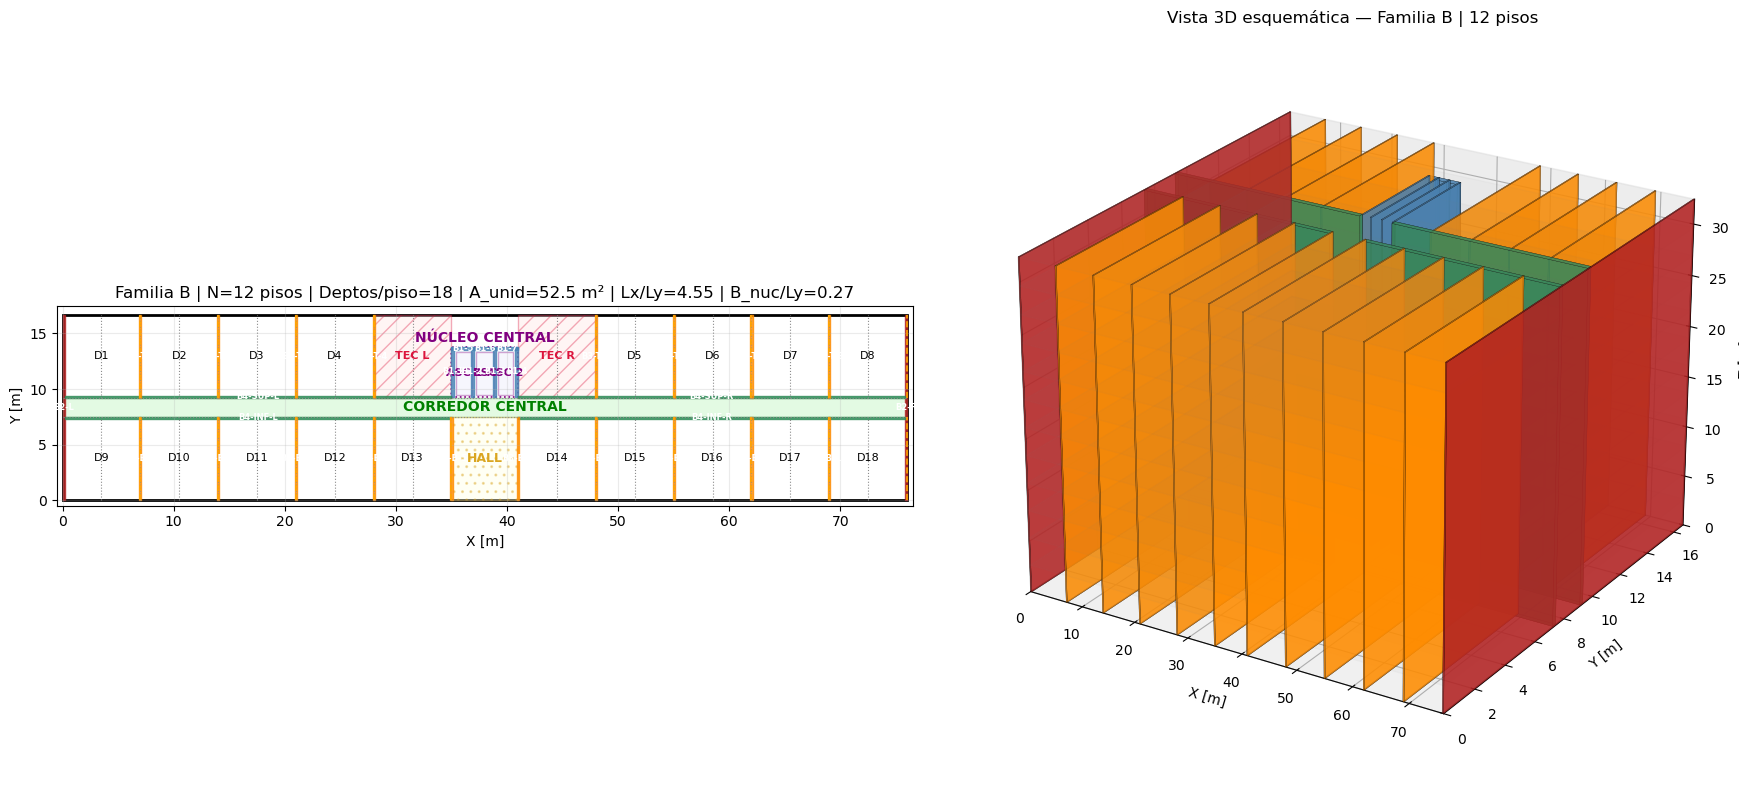

In [14]:
# Visualización planta + 3D
print("="*90)
print("VISUALIZACIÓN DE LA FAMILIA B")
print("="*90)
fig = plt.figure(figsize=(18, 8))
ax1 = fig.add_subplot(1, 2, 1)
plot_family_B_plan(geom_B, params_B, ax=ax1, show_labels=True)
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
plot_family_B_3D(geom_B, params_B, ax=ax2)
plt.tight_layout()
plt.show()

## 💾 Exportación oficial de la Familia B

Paso de cierre que persiste los entregables en `outputs/familia_B/`:

1. **`familia_B_master.json`** — la configuración maestra `FAMILIA_B_CFG` completa (rangos, restricciones y grupos de muros), serializada con indentación y UTF-8.
2. **`familia_B_core.py`** — el código fuente de las ocho funciones núcleo (`rect_dict`, `sample_from_spec`, `build_params_B`, `build_family_B_geometry`, las dos tablas y los dos ploteos), extraído con `inspect.getsource` y precedido de los imports necesarios.

Esto **desacopla** la definición de la familia del notebook, dejándola reutilizable por las etapas posteriores del pipeline.

**Se obtiene:** los dos artefactos oficiales (JSON de configuración + módulo `.py`) que sirven de entrada a la generación del dataset y al modelo estructural.

In [15]:
# ============================================================
# EXPORTACIÓN OFICIAL — FAMILIA B
# ============================================================
import json
from pathlib import Path
import inspect

# Carpeta de salida
OUT_DIR = Path("outputs") / "familia_B"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1) Guardar configuración oficial de la familia
# ------------------------------------------------------------
cfg_path = OUT_DIR / "familia_B_master.json"

with open(cfg_path, "w", encoding="utf-8") as f:
    json.dump(FAMILIA_B_CFG, f, indent=4, ensure_ascii=False)

print(f"Configuración oficial guardada en: {cfg_path}")

# ------------------------------------------------------------
# 2) Guardar funciones principales en un archivo .py
# ------------------------------------------------------------
core_path = OUT_DIR / "familia_B_core.py"

functions_to_export = [
    rect_dict,
    sample_from_spec,
    build_params_B,
    build_family_B_geometry,
    wall_group_table_B,
    variable_table_B,
    plot_family_B_plan,
    plot_family_B_3D,
]

with open(core_path, "w", encoding="utf-8") as f:
    f.write("# ============================================================\n")
    f.write("# familia_B_core.py\n")
    f.write("# Archivo generado automáticamente desde Notebook 1\n")
    f.write("# ============================================================\n\n")
    f.write("import numpy as np\n")
    f.write("import pandas as pd\n")
    f.write("import matplotlib.pyplot as plt\n")
    f.write("from matplotlib.patches import Rectangle\n")
    f.write("from mpl_toolkits.mplot3d.art3d import Poly3DCollection\n")
    f.write("from pprint import pprint\n\n")

    for fn in functions_to_export:
        f.write("\n\n")
        f.write(inspect.getsource(fn))

print(f"Funciones oficiales guardadas en: {core_path}")

# ------------------------------------------------------------
# 3) Chequeo rápido
# ------------------------------------------------------------
print("="*90)
print("EXPORTACIÓN COMPLETADA")
print("="*90)
print(f"Archivo JSON: {cfg_path.resolve()}")
print(f"Archivo CORE: {core_path.resolve()}")

Configuración oficial guardada en: outputs\familia_B\familia_B_master.json
Funciones oficiales guardadas en: outputs\familia_B\familia_B_core.py
EXPORTACIÓN COMPLETADA
Archivo JSON: C:\Users\rodri\Documents\PINN\b2_proyecto\notebooks\outputs\familia_B\familia_B_master.json
Archivo CORE: C:\Users\rodri\Documents\PINN\b2_proyecto\notebooks\outputs\familia_B\familia_B_core.py


## ✅ Conclusiones

- La Familia B encapsula una tipología habitacional concreta y coherente: barra con corredor central, núcleo centrado y departamentos de 2 módulos continuos (sin muro estructural al interior del departamento).
- El núcleo **no flota** entre el corredor y los departamentos superiores: arranca justo sobre el corredor y se interna dentro de la profundidad del departamento superior, reemplazando el área habitable en esa zona. La condición $prof_{depto} \geq B_{nucleo} + gap$ garantiza que el núcleo no salga de la planta; con los rangos actuales siempre se satisface.
- La restricción $B_{nucleo} / L_y \leq 0.45$ es nueva en esta versión y previene que el núcleo ocupe una fracción excesiva del ancho de la planta, lo que comprometería el programa habitable del departamento superior.
- El límite de área mínima de 30 m² es redundante con los rangos actuales (mínimo real ~44.8 m²), pero actúa como salvaguarda si en el futuro se amplía el espacio paramétrico.
- La fórmula $E = 4700\sqrt{f'_c}$ elimina el módulo de elasticidad como variable libre: dado el hormigón, la rigidez queda determinada.
- La geometría generada por `build_family_B_geometry` es el input directo al constructor del modelo estructural OpenSees (`build_model.py`), que la traduce en nodos, elementos y condiciones de contorno.